# Análise Integrada de HIV em Gestantes

Este notebook unifica as análises feitas em abordagens separadas, reunindo as etapas de:
1. **Tratamento Fidedigno para Python** (Remoção de Duplicadas e Limpeza por Dicionários DataSUS, Testes Estatísticos Qui-Quadrado)
2. **Exploração Demográfica, Geográfica e Modelagem Avançada (Séries Temporais e Machine Learning)**

Ambas as lógicas foram devidamente combinadas de forma otimizada numa única pipeline.


## 1. Importação de Bibliotecas e Configurações
Nesta etapa, importamos todas as bibliotecas necessárias para manipulação de dados (`pandas`, `numpy`), análise estatística (`scipy`), visualização de dados (`matplotlib`, `seaborn`), aprendizado de máquina e modelagem preditiva (`sklearn`, `statsmodels`, `prophet`), bem como ferramentas para análise de dados espaciais (`geobr`). Adicionalmente, ajustamos as configurações visuais globais para os gráficos.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy.stats import chi2_contingency
from IPython.display import display

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except:
    PROPHET_AVAILABLE = False

try:
    import geobr
    GEOBR_AVAILABLE = True
except:
    GEOBR_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="magma")
plt.rcParams['figure.figsize'] = (14, 7)
GEOBR_AVAILABLE = True

### 1. Leitura de Arquivos CSV
Nesta etapa, lemos todos os arquivos `.dbc` presentes na subpasta `Banco-dados`. Cada arquivo é convertido para `.dbf` temporariamente, lido e depois apagado.

In [72]:
# Carregar dados diretamente do CSV consolidado
csv_file = '../data/HIV-Gestante-2018-2024.csv'
print(f"Lendo arquivo: {csv_file}")
data_raw = pd.read_csv(csv_file, encoding='utf-8')

# --- FILTRO 2024 OBRIGATÓRIO: Trabalhar com dados somente até Dezembro de 2023 ---
data_raw = data_raw[data_raw['NU_ANO'] < 2024].copy()
print("Número total de linhas antes da remoção de duplicatas:", len(data_raw))


Lendo arquivo: ../data/HIV-Gestante-2018-2024.csv
Número total de linhas antes da remoção de duplicatas: 49601


### 2. Tratamento e Identificação de Duplicatas
Vamos buscar linhas duplicadas levando em consideração todas as colunas de notificação e datas.

In [73]:
# Verificar duplicatas com base nas colunas escolhidas no R
cols_dup = [
    'TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'NU_ANO', 'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 
    'DT_DIAG', 'SEM_DIAG', 'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 
    'SG_UF', 'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS', 'ANT_EVLABO', 'PRE_PRENAT', 'PRE_UFREL', 
    'PRE_MUNIRE', 'PRE_ANTRET', 'PRE_DT_RET', 'PAR_UFPART', 'PRE_MUNIPA', 'PAR_DT_PAR', 
    'PAR_TIPO', 'PAR_ANTIDU', 'PAR_EVOLUC', 'PAR_INICPR'
]

# Quantas duplicatas nós temos?
duplicados = data_raw[data_raw.duplicated(subset=cols_dup, keep=False)]
print(f"Duplicatas encontradas: {len(duplicados)}")

# Remover duplicatas mantendo apenas o primeiro registro
data = data_raw.drop_duplicates(subset=cols_dup, keep='first').copy()
print("Linhas depois (sem duplicatas):", len(data))

# Cuidar da conversão de variáveis numéricas necessárias (para posterior categorização)
num_cols = ['ANT_EVLABO', 'PRE_PRENAT', 'PAR_TIPO', 'CS_RACA', 'CS_ESCOL_N', 'PAR_EVOLUC', 'NU_ANO', 'SG_UF', 'NU_IDADE_N']
for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

    # --- FILTRO DE IDADE OBRIGATORIO: Apenas mulheres de 10 a 55 anos (removendo outliers) ---
    # A idade padrao do DataSUS vem em formato codificado onde 4000+ sao anos
    # Isolamos apenas os anos e depois filtramos:
    data['IDADE_REAL_TEMP'] = data['NU_IDADE_N'].apply(lambda x: int(str(int(x))[1:4]) if pd.notnull(x) and x > 4000 else np.nan)
    data = data[(data['IDADE_REAL_TEMP'] >= 10) & (data['IDADE_REAL_TEMP'] <= 55)].copy()
    data.drop(columns=['IDADE_REAL_TEMP'], inplace=True)
print(f"\nTotal de registros pós-filtro de idade (10 a 55 anos): {len(data)}")

# Gerar data verdadeira (Para o Script de Machine learning e o Reporting Lag)
data['DT_NOTIFIC'] = pd.to_datetime(data['DT_NOTIFIC'], errors='coerce')
data['ANO'] = data['DT_NOTIFIC'].dt.year
data = data.dropna(subset=['DT_NOTIFIC']).copy()

# --- FILTRO DINAMICO: Remove meses com atraso de notificacao (Reporting Lag) (Lógica do Pedro) ---
# A partir de Jul/2024 os dados do SINAN ficam incompletos (lag de processamento)
ts_raw = data.resample('M', on='DT_NOTIFIC').size()
# Proteção caso Pandas versão velha: tentar 'M'
try:
    ts_raw = data.resample('M', on='DT_NOTIFIC').size()
except ValueError:
    ts_raw = data.resample('M', on='DT_NOTIFIC').size()

media_historica = ts_raw.iloc[:-12].mean()
meses_validos = ts_raw[ts_raw > (media_historica * 0.30)].index
ultima_data_valida = meses_validos.max()
data = data[data['DT_NOTIFIC'] <= ultima_data_valida].copy()

print(f"\nPeríodo útil ajustado (sem LAG): até {ultima_data_valida.strftime('%m/%Y')}")
print("Total de registros pós-filtro temporal:", len(data))

print('[Lógica Pedro Aplicada]: Verificação -> Data final retida no DataFrame:', data['DT_NOTIFIC'].max())

Duplicatas encontradas: 18
Linhas depois (sem duplicatas): 49592

Total de registros pós-filtro de idade (10 a 55 anos): 48980

Período útil ajustado (sem LAG): até 12/2023
Total de registros pós-filtro temporal: 48980
[Lógica Pedro Aplicada]: Verificação -> Data final retida no DataFrame: 2023-12-31 00:00:00


### 3. Definição do Dicionário (Recodificação)
Aplicaremos os mapeamentos baseados em categorias documentadas.

In [74]:
# dicionário: diagnóstico
diag_map = {1: "Antes Pré-Natal", 2: "Durante Pré-Natal", 3: "Durante o parto", 4: "Após parto"}
data['diagnostico'] = data['ANT_EVLABO'].map(diag_map)

# dicionário: ano
ano_map = {2018: "2018",2019: "2019",2020: "2020", 2021: "2021", 2022: "2022", 2023: "2023", 2024: "2024"}
data['ano'] = data['NU_ANO'].map(ano_map)

# dicionário: preNatal
prenat_map = {1: "Sim", 2: "Não", 3: "Ignorado"}
data['preNatal'] = data['PRE_PRENAT'].map(prenat_map)

# dicionário: tipo de parto
tipo_parto_map = {1: "Vaginal", 2: "Cesárea eletiva", 3: "Cesárea Urgência"}
data['tipoParto'] = data['PAR_TIPO'].map(tipo_parto_map)

# dicionário: raca/cor
raca_map = {1: "Branca", 2: "Preta", 3: "Amarela", 4: "Parda", 5: "Indígena"}
data['cs_raca'] = data['CS_RACA'].map(raca_map)

# dicionário: escolaridade
def map_escolaridade(x):
    if pd.isna(x): return np.nan
    x = int(x)
    if x == 43: return "Analfabeto"
    if x in [1, 2, 3]: return "Fundamental Incompleto"
    if x == 4: return "Fundamental Completo"
    if x == 5: return "Médio Incompleto"
    if x == 6: return "Médio Completo"
    if x == 7: return "Superior Incompleto"
    if x == 8: return "Superior Completo"
    return np.nan
data['cs_escol_n'] = data['CS_ESCOL_N'].apply(map_escolaridade)

# Correção e cálculo da idade a partir do campo NU_IDADE_N padrão do datasus
# Geralmente a idade é dada por um código (1xx = horas, 2xx = dias, 3xx = meses, 4xx = anos)
def calc_idade(x):
    if pd.isna(x): return np.nan
    if x <= 4000: return 0  # <1 ano
    if x > 4000: return int(str(int(x))[1:4])
    return np.nan
data['idade_anos'] = data['NU_IDADE_N'].apply(calc_idade)

# Categoria da Idade
def cat_idade(idade):
    if pd.isna(idade): return "N/A"
    if 10 <= idade <= 19: return "Adolescente (10 - 19 anos)"
    if 20 <= idade <= 29: return "Jovem Adulta (20 - 29 anos)"
    if 30 <= idade <= 39: return "Adulta (30 - 39 anos)"
    if idade >= 40: return "Adulta (acima de 40)"
    return "N/A"
data['idade_categoria'] = data['idade_anos'].apply(cat_idade)

# Transformação das categorias de idade para "Categorical" do Pandas de forma a ordenar em visualizações
idade_cats = ["Adolescente (10 - 19 anos)", "Jovem Adulta (20 - 29 anos)", "Adulta (30 - 39 anos)", "Adulta (acima de 40)", "N/A"]
data['idade_categoria'] = pd.Categorical(data['idade_categoria'], categories=idade_cats, ordered=True)

# Classificação por Região
def get_regiao(uf):
    if pd.isna(uf): return "N/A"
    uf = int(uf)
    if uf in [12, 13, 16, 15, 11, 14, 17]: return "Norte"
    if uf in [27, 29, 23, 21, 25, 26, 22, 24, 28]: return "Nordeste"
    if uf in [52, 51, 50]: return "Centro-Oeste"
    if uf == 53: return "Distrito Federal"
    if uf in [32, 31, 33, 35]: return "Sudeste"
    if uf in [41, 42, 43]: return "Sul"
    return "N/A"
data['regiao'] = data['SG_UF'].apply(get_regiao)


### 3.1. Adaptações de Engenharia de Dados (Transição para ML)

In [75]:
# Adaptação para Análises Multivariadas e Modelagem
# Criaremos as principais referências temporais e geográficas exigidas nos modelos preditivos

df = data.copy()

# A análise do Pedro requer nomes específicos e variáveis limpas:
df['IDADE_REAL'] = df['idade_anos'].replace(0, np.nan) # Evitar distorções onde 0 poderia ser <1
df['ANO'] = pd.to_numeric(df['ano'], errors='coerce')
df['SG_UF_NUM'] = pd.to_numeric(df['SG_UF'], errors='coerce')

# Convertendo DT_NOTIFIC para datetime a fim de podermos criar as Séries Temporais
# DT_NOTIFIC original: '20201015' (YYYYMMDD) etc
df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], format='%Y%m%d', errors='coerce')

print("Adaptações do DataFrame concluídas.")


Adaptações do DataFrame concluídas.


### 4. Resumos de Frequência Básica
Validando algumas distribuições.

In [76]:
print("=== Diagnóstico ===")
print(data['diagnostico'].value_counts(dropna=False))
print("")
print("=== Categoria da Idade ===")
print(data['idade_categoria'].value_counts(dropna=False))


=== Diagnóstico ===
diagnostico
Antes Pré-Natal      28734
Durante Pré-Natal    17282
Durante o parto       2531
Após parto             427
NaN                      6
Name: count, dtype: int64

=== Categoria da Idade ===
idade_categoria
Jovem Adulta (20 - 29 anos)    25076
Adulta (30 - 39 anos)          15425
Adolescente (10 - 19 anos)      6480
Adulta (acima de 40)            1999
N/A                                0
Name: count, dtype: int64


### 5. Casos Acumulados por Região/Ano
Gráfico de linhas da evolução.

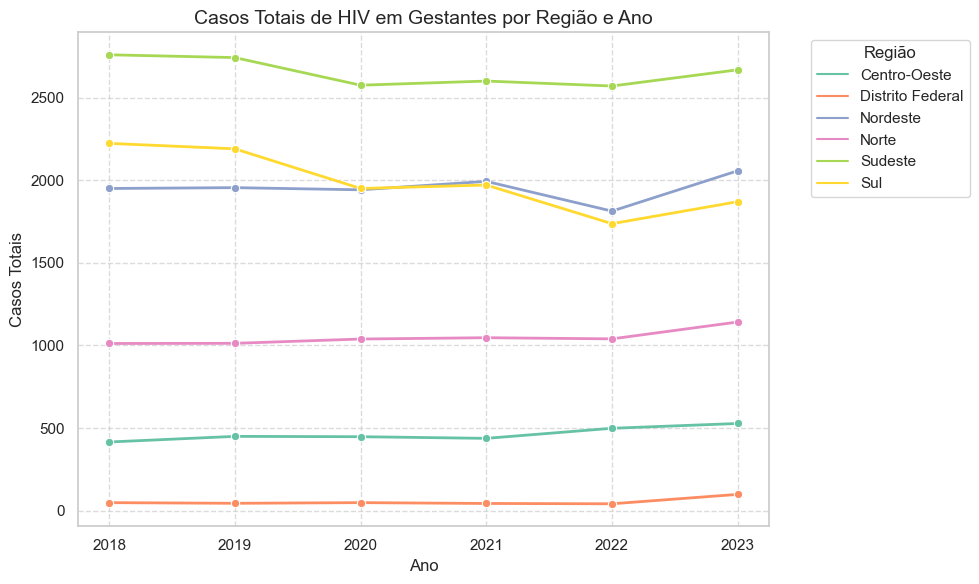

In [87]:
# Filtrar valores não preenchidos
dados_agrupados_regiao = data[data['regiao'] != "N/A"].groupby(['ano', 'regiao']).size().reset_index(name='casos_totais')

plt.figure(figsize=(10, 6))

# Alteração feita aqui: adição do palette='Set2'
sns.lineplot(data=dados_agrupados_regiao, x='ano', y='casos_totais', hue='regiao', palette='Set2', marker='o', linewidth=2)

plt.title("Casos Totais de HIV em Gestantes por Região e Ano", fontsize=14)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Casos Totais", fontsize=12)
plt.legend(title="Região", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Insights:
Os dados mostram que as regiões mais populosas concentram maior número absoluto de casos de HIV em gestantes, refletindo a distribuição populacional do país. Observa-se uma redução dos casos em 2020, provavelmente relacionada ao impacto da pandemia de COVID-19, que comprometeu o acesso ao pré-natal e à testagem. Além disso, diferenças regionais podem estar associadas a desigualdades no acesso aos serviços de saúde e às tecnologias de diagnóstico, o que influencia a detecção e a notificação dos casos.

Referências:
- https://www.gov.br/saude/pt-br/centrais-de-conteudo/publicacoes/boletins/epidemiologicos/especiais/2025/boletim-epidemiologico-de-hiv-e-aids-numero-especial-dez-2025.pdf

- OLIVEIRA, Ricardo Antunes Dantas de et al. Barreiras de acesso aos serviços em cinco Regiões de Saúde do Brasil: percepção de gestores e profissionais do Sistema Único de Saúde. Cadernos de saúde Pública, v. 35, p. e00120718, 2019.

### 6. Teste de Qui-Quadrado: Idade Categoria x Pré-natal

Tabela de Contingência (sem Ignorado e N/A):



preNatal,Não,Sim
idade_categoria,,
Adolescente (10 - 19 anos),330,5932
Jovem Adulta (20 - 29 anos),1503,22738
Adulta (30 - 39 anos),957,13889
Adulta (acima de 40),110,1802



Resultado do Teste Qui-Quadrado:
Chi-quadrado = 11.2962, p-value = 0.010227474721286751


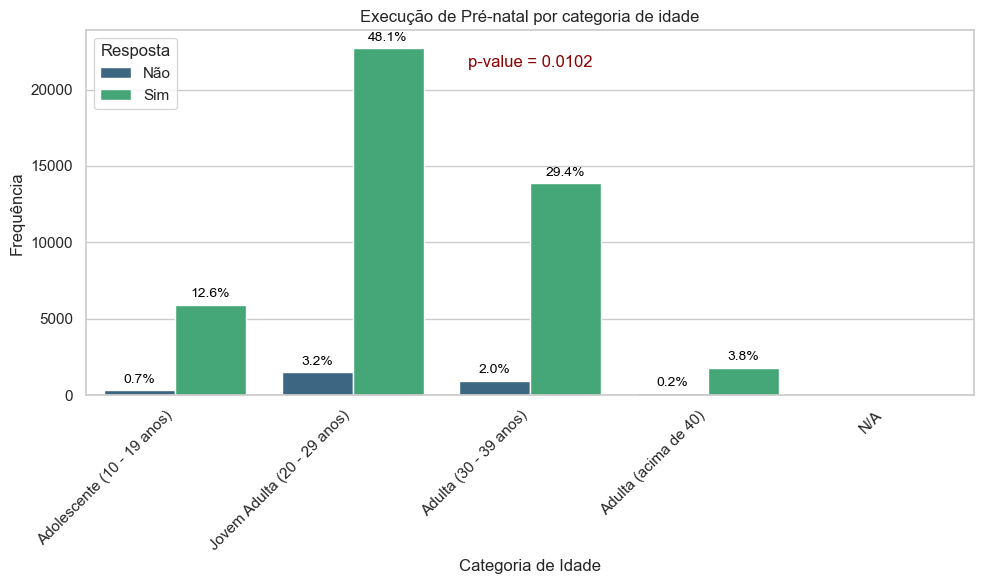

In [95]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Remover linhas com NA nas categorias, "N/A" e Ignorados
df_q1 = data.dropna(subset=['idade_categoria', 'preNatal'])
df_q1 = df_q1[(df_q1['idade_categoria'] != 'N/A') & (df_q1['preNatal'] != 'Ignorado')]

# Tabela de Contingência
tabela_contingencia = pd.crosstab(df_q1['idade_categoria'], df_q1['preNatal'])
print("Tabela de Contingência (sem Ignorado e N/A):\n")
display(tabela_contingencia)

# Teste
chi2, p_value, dof, expected = chi2_contingency(tabela_contingencia)
print(f"\nResultado do Teste Qui-Quadrado:")
print(f"Chi-quadrado = {chi2:.4f}, p-value = {p_value}")

# Transformar a tabela para o formato longo exigido pelo gráfico
tabela_df = tabela_contingencia.reset_index().melt(id_vars='idade_categoria', var_name='Resposta', value_name='Frequencia')

# Garantir que a categoria "N/A" seja excluída definitivamente do gráfico, 
# mesmo se ainda constar como índice invisível na categoria original
tabela_df = tabela_df[tabela_df['idade_categoria'] != 'N/A']

# Configuração e Criação do Gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=tabela_df, x='idade_categoria', y='Frequencia', hue='Resposta', palette='viridis')

plt.title("Execução de Pré-natal por categoria de idade")
plt.xlabel("Categoria de Idade")
plt.ylabel("Frequência")
plt.xticks(rotation=45, ha='right')

# --- ADIÇÃO DAS PORCENTAGENS ---
# Pega o total absoluto apenas dos dados mostrados nessa tabela (Ex: 330 + 5932 + 1503 + ... = ~47000)
total_casos_validos = tabela_contingencia.values.sum()

# Iterar sobre todas as barras (patches) desenhadas no gráfico e anotar as porcentagens usando as frequências encontradas na tabela
for p in ax.patches:
    altura = p.get_height()
    # Pula barras vazias ou valores nulos (para não ter divisão por zero)
    if not np.isnan(altura) and altura > 0:
        # A Porcentagem baseando-se no total da tabela de contingencia 
        porcentagem = f'{(altura / total_casos_validos) * 100:.1f}%'
        
        # Anota o texto no topo da barra
        ax.annotate(porcentagem, 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', 
                    xytext=(0, 3), 
                    textcoords='offset points')

# Add p-value annotation
plt.annotate(f"p-value = {p_value:.4f}", 
             xy=(0.5, 0.9), xycoords='axes fraction', 
             fontsize=12, color='darkred', ha='center')

plt.tight_layout()
plt.show()


Insights:

- Embora o teste qui-quadrado tenha indicado associação estatisticamente significativa (p = 0,010), as diferenças nas proporções de adesão entre os grupos etários foram clinicamente irrelevantes (variação de 1,1%), sugerindo que a adesão ao pré-natal é uniformemente elevada independentemente da faixa etária.

### 7. Teste de Qui-Quadrado: Tipo de Parto x Pré-natal

Tabela de Contingência (Parto x Pré-Natal):


tipoParto,Cesárea Urgência,Cesárea eletiva,Vaginal
preNatal,,,
Não,423,505,1078
Sim,3519,16510,7977



Chi-quadrado = 875.9317, p-value = 6.220770172875718e-191


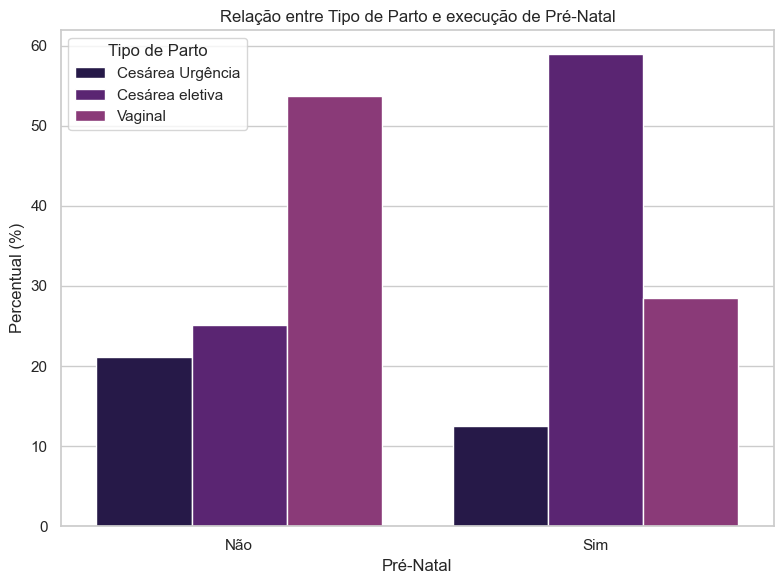

In [ ]:
df_q2 = data.dropna(subset=['preNatal', 'tipoParto'])
df_q2 = df_q2[(df_q2['preNatal'] != 'Ignorado') & (df_q2['tipoParto'] != 'Ignorado')]

tabela2 = pd.crosstab(df_q2['preNatal'], df_q2['tipoParto'])
chi2_2, p_value2, dof2, exp2 = chi2_contingency(tabela2)

print("Tabela de Contingência (Parto x Pré-Natal):")
display(tabela2)
print(f"\nChi-quadrado = {chi2_2:.4f}, p-value = {p_value2}")

# Percentuais em gráfico stack
df_q2_pct = (tabela2.div(tabela2.sum(axis=1), axis=0) * 100).reset_index().melt(id_vars='preNatal', var_name='Tipo de Parto', value_name='Percentual')

plt.figure(figsize=(8, 6))
sns.barplot(data=df_q2_pct, x='preNatal', y='Percentual', hue='Tipo de Parto')
plt.title(f"Relação entre Tipo de Parto e execução de Pré-Natal") #(p-value = {p_value2:.2e})
plt.xlabel("Pré-Natal")
plt.ylabel("Percentual (%)")
plt.tight_layout()
plt.show()


### 8. Momento do Diagnóstico x Idade

idade_categoria,Adolescente (10 - 19 anos),Jovem Adulta (20 - 29 anos),Adulta (30 - 39 anos),Adulta (acima de 40)
diagnostico,,,,
Antes Pré-Natal,3522,14295,9630,1287
Após parto,49,231,127,20
Durante Pré-Natal,2563,9211,4915,593
Durante o parto,346,1335,751,99


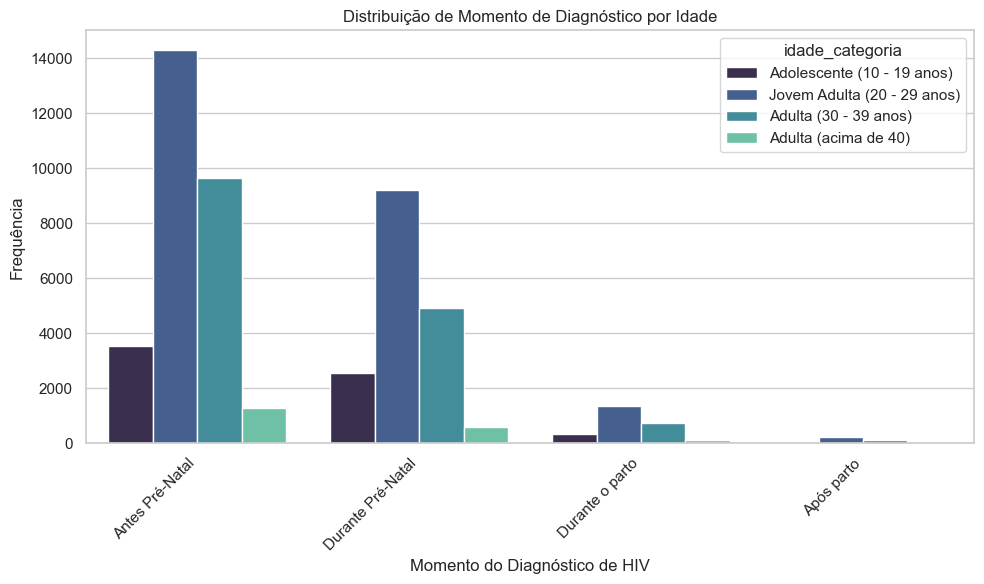

In [ ]:
df_q3 = data.dropna(subset=['diagnostico', 'idade_categoria'])
df_q3 = df_q3[df_q3['idade_categoria'] != 'N/A']

tabela3 = pd.crosstab(df_q3['diagnostico'], df_q3['idade_categoria'])
display(tabela3)

tabela3_df = tabela3.reset_index().melt(id_vars='diagnostico', var_name='idade_categoria', value_name='Frequencia')

plt.figure(figsize=(10, 6))

ordem_diagnostico = ["Antes Pré-Natal", "Durante Pré-Natal", "Durante o parto", "Após parto"]
sns.barplot(data=tabela3_df, x='diagnostico', y='Frequencia', hue='idade_categoria', palette='mako', order=ordem_diagnostico)

plt.title("Distribuição de Momento de Diagnóstico por Idade")
plt.xlabel("Momento do Diagnóstico de HIV")
plt.ylabel("Frequência")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 9. Teste de Qui-Quadrado: Escolaridade x Pré-natal

Tabela de Contingência (Escolaridade x Pré-Natal):


preNatal,Não,Sim
cs_escol_n,,
Fundamental Completo,282,4756
Fundamental Incompleto,1056,11511
Médio Completo,428,11110
Médio Incompleto,332,5842
Superior Completo,28,1463
Superior Incompleto,30,1074



Chi-quadrado = 316.6260, p-value = 2.662470435877547e-66


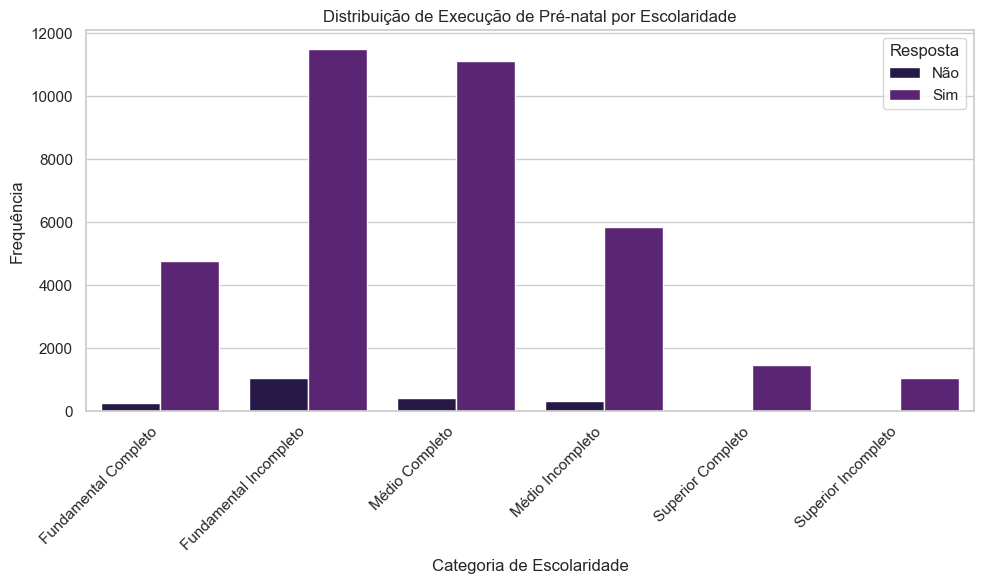

In [ ]:
df_q4 = data.dropna(subset=['cs_escol_n', 'preNatal'])
df_q4 = df_q4[df_q4['preNatal'] != 'Ignorado']

tabela4 = pd.crosstab(df_q4['cs_escol_n'], df_q4['preNatal'])
chi2_4, p_value4, dof4, exp4 = chi2_contingency(tabela4)

print("Tabela de Contingência (Escolaridade x Pré-Natal):")
display(tabela4)
print(f"\nChi-quadrado = {chi2_4:.4f}, p-value = {p_value4}")

tabela4_df = tabela4.reset_index().melt(id_vars='cs_escol_n', var_name='Resposta', value_name='Frequencia')

plt.figure(figsize=(10, 6))
sns.barplot(data=tabela4_df, x='cs_escol_n', y='Frequencia', hue='Resposta')
plt.title("Distribuição de Execução de Pré-natal por Escolaridade")
plt.xlabel("Categoria de Escolaridade")
plt.ylabel("Frequência")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


## 5. EDA Expandida e Distribuição Demográfica

--- Estatísticas Descritivas ---


,count,mean,std,min,25%,50%,75%,max
IDADE_REAL,48980.0,27.131094,6.745231,10.0,22.0,27.0,32.0,55.0
ANO,48980.0,2020.477134,1.721151,2018.0,2019.0,2020.0,2022.0,2023.0


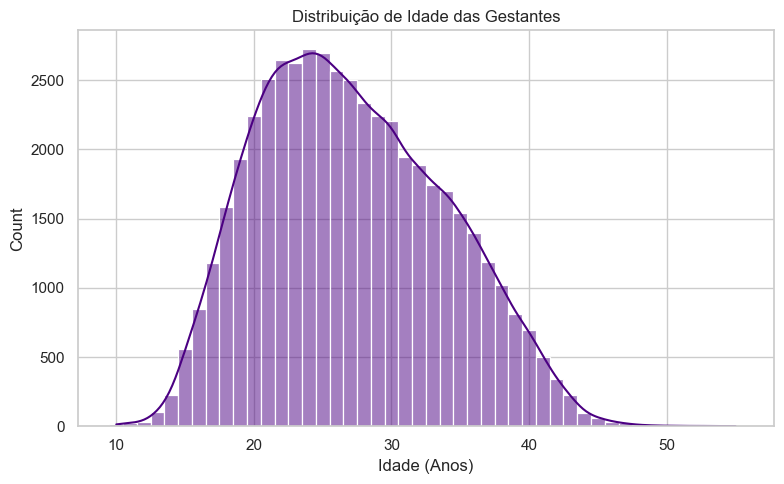

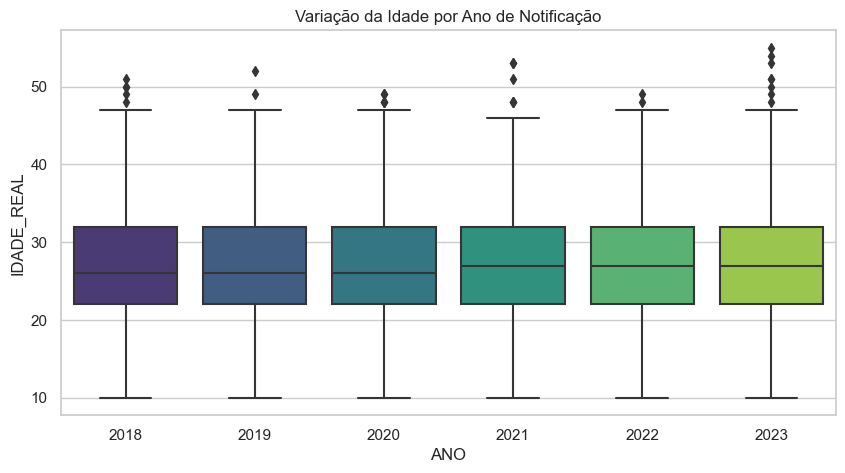

In [ ]:
print("--- Estatísticas Descritivas ---")
display(df[['IDADE_REAL', 'ANO']].describe().T)

# Distribuição de Idade
plt.figure(figsize=(8, 5))
sns.histplot(df['IDADE_REAL'].dropna(), bins=30, discrete=True, kde=True, color='indigo')
plt.title('Distribuição de Idade das Gestantes')
plt.xlabel('Idade (Anos)')
plt.tight_layout()
plt.show()

# Boxplot de Variação da Idade
plt.figure(figsize=(10, 5))
sns.boxplot(x='ANO', y='IDADE_REAL', data=df, palette='viridis')
plt.title("Variação da Idade por Ano de Notificação")
plt.show()


## 3. Inteligência Geográfica: Taxa Proporcional por UF

Mapas baseados em taxas proporcionais (%) para evitar distorções populacionais brutas.

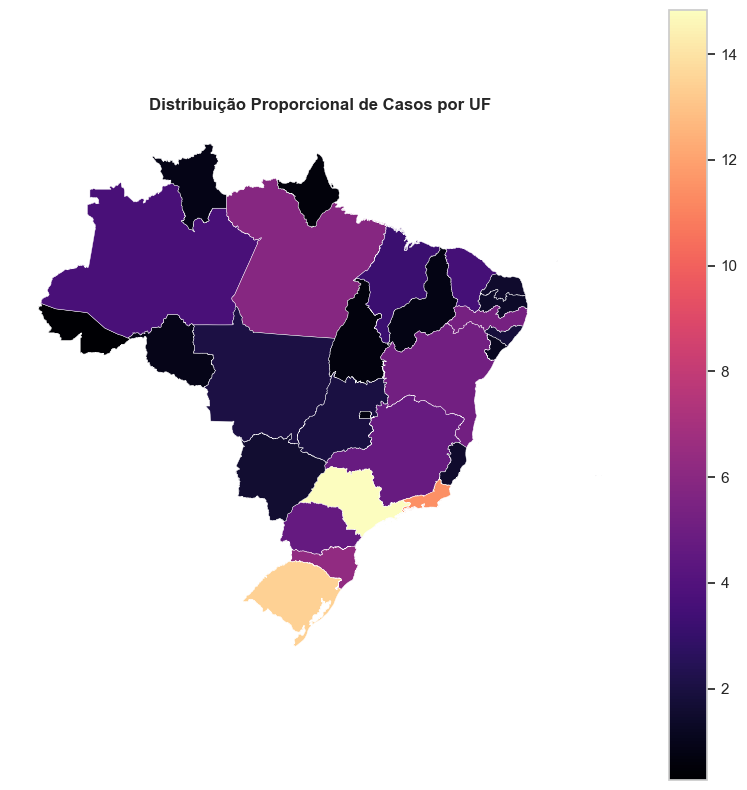

Top 5 Estados com maior incidência relativa:
SG_UF_NOT
São Paulo            7280
Rio Grande do Sul    6579
Rio de Janeiro       5603
Santa Catarina       3076
Pará                 2859
Name: count, dtype: int64


In [ ]:
if GEOBR_AVAILABLE:
    try:
        uf_percent = df['SG_UF_NUM'].value_counts(normalize=True).reset_index()
        uf_percent.columns = ['code_state', 'Taxa (%)']
        uf_percent['Taxa (%)'] *= 100
        
        states = geobr.read_state(year=2020)
        map_data = states.merge(uf_percent, on='code_state')
        
        fig, ax = plt.subplots(figsize=(10, 10))
        map_data.plot(column='Taxa (%)', cmap='magma', legend=True, ax=ax, edgecolor='white', linewidth=0.3)
        ax.set_title('Distribuição Proporcional de Casos por UF', fontweight='bold')
        ax.axis('off')
        plt.show()
    except Exception as e: print(f"Mapa não gerado: {e}")

# 1. Crie o dicionário com os códigos do IBGE para cada estado
mapa_estados = {
    11: 'Rondônia', 12: 'Acre', 13: 'Amazonas', 14: 'Roraima', 15: 'Pará', 16: 'Amapá', 17: 'Tocantins',
    21: 'Maranhão', 22: 'Piauí', 23: 'Ceará', 24: 'Rio Grande do Norte', 25: 'Paraíba', 26: 'Pernambuco', 27: 'Alagoas', 28: 'Sergipe', 29: 'Bahia',
    31: 'Minas Gerais', 32: 'Espírito Santo', 33: 'Rio de Janeiro', 35: 'São Paulo',
    41: 'Paraná', 42: 'Santa Catarina', 43: 'Rio Grande do Sul',
    50: 'Mato Grosso do Sul', 51: 'Mato Grosso', 52: 'Goiás', 53: 'Distrito Federal'
}

print("Top 5 Estados com maior incidência relativa:")
try:
    # 2. Converta a coluna para número inteiro (caso esteja como texto) e aplique o mapa
    top_5 = df['SG_UF_NOT'].fillna(0).astype(int).map(mapa_estados).value_counts().head(5)
    print(top_5)
except KeyError:
    print("Coluna 'SG_UF_NOT' não encontrada.")

## 4. Séries Temporais: Limpeza, MA30 e Volatilidade

**Ação Crítica:** Removemos o último mês da série temporal, que apresenta queda artificial devido ao atraso de processamento do SINAN.

📌 ÚLTIMA DATA CONSIDERADA (Pós-limpeza): 11/2023

Crescimento anual (%) das notificações:
ds
2018-12-31         NaN
2019-12-31   -0.154523
2020-12-31   -4.714286
2021-12-31    1.136932
2022-12-31   -4.842495
2023-12-31    1.505907
Freq: A-DEC, Name: y, dtype: float64


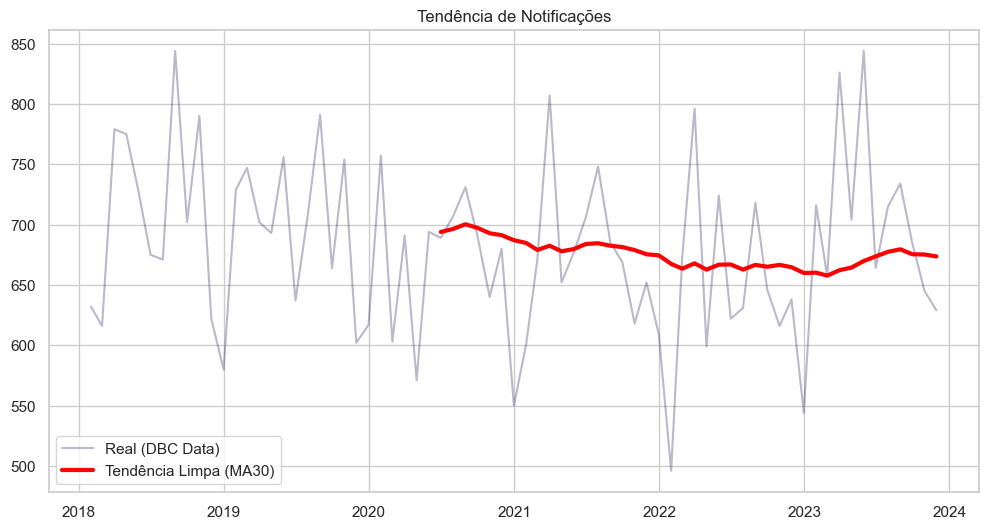

In [ ]:
ts = df.resample('M', on='DT_NOTIFIC').size().reset_index(name='y')
ts.columns = ['ds', 'y']

# 🔥 Limpeza Inteligente: Remove o último mês para evitar queda artificial na tendência
ultima_data_real = ts['ds'].max()
ts = ts[ts['ds'] < ultima_data_real]
ts = ts[ts['ds'] > '2017-12-31']

print(f"📌 ÚLTIMA DATA CONSIDERADA (Pós-limpeza): {ts['ds'].max().strftime('%m/%Y')}")

ts['MA7'] = ts['y'].rolling(window=7).mean()
ts['MA30'] = ts['y'].rolling(window=30).mean()
ts['Volatilidade'] = ts['y'].rolling(window=12).std()

print("\nCrescimento anual (%) das notificações:")
print(ts.resample('Y', on='ds')['y'].sum().pct_change() * 100)

plt.figure(figsize=(12,6))
plt.plot(ts['ds'], ts['y'], alpha=0.3, label='Real (DBC Data)')
plt.plot(ts['ds'], ts['MA30'], linewidth=3, color='red', label='Tendência Limpa (MA30)')
plt.title("Tendência de Notificações")
plt.legend()
plt.show()

In [ ]:
def safe_forecast(ts, periods=12):
    if PROPHET_AVAILABLE:
        try:
            m = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.05)
            m.fit(ts[['ds', 'y']])
            future = m.make_future_dataframe(periods=periods, freq='M')
            forecast = m.predict(future)
            return forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], "Prophet"
        except Exception as e:
            print(f"⚠️ Prophet indisponivel: {e}. Usando Holt-Winters...")
    
    # Fallback: Holt-Winters com sazonalidade anual
    try:
        model = ExponentialSmoothing(ts['y'], seasonal_periods=12, trend='add', seasonal='add').fit()
        forecast_vals = model.forecast(periods)
        fitter_type = "Holt-Winters"
        fitted_vals = model.fittedvalues
    except Exception as e2:
        model = ExponentialSmoothing(ts['y'], trend='add').fit()
        forecast_vals = model.forecast(periods)
        fitter_type = "Holt-Simples"
        fitted_vals = model.fittedvalues
    
    last_date = ts['ds'].max()
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=periods, freq='M')
    
    history = pd.DataFrame({'ds': ts['ds'], 'yhat': fitted_vals})
    future  = pd.DataFrame({'ds': future_dates, 'yhat': forecast_vals.values})
    full    = pd.concat([history, future], ignore_index=True)
    
    std = ts['y'].std()
    full['yhat_lower'] = full['yhat'] - 1.5 * std
    full['yhat_upper'] = full['yhat'] + 1.5 * std
    
    return full, fitter_type

## 5. Backtesting e Projeção: Prophet vs RandomForest

Avaliação da capacidade preditiva usando os **últimos 6 meses como conjunto de teste (real)**\n
e projeção até **Dezembro de 2026** com os dois modelos.

Treino: Jan/2018 -> Dec/2022 (60 meses)
Teste:  Jan/2023  -> Dec/2023  (12 meses)
Projeção futura: 48 meses após Dec/2023 -> Dez/2027

--- Métricas de Backtesting (12 meses) ---
Holt-Winters     MAE=60.8  RMSE=77.7
RandomForest    MAE=67.0  RMSE=82.7


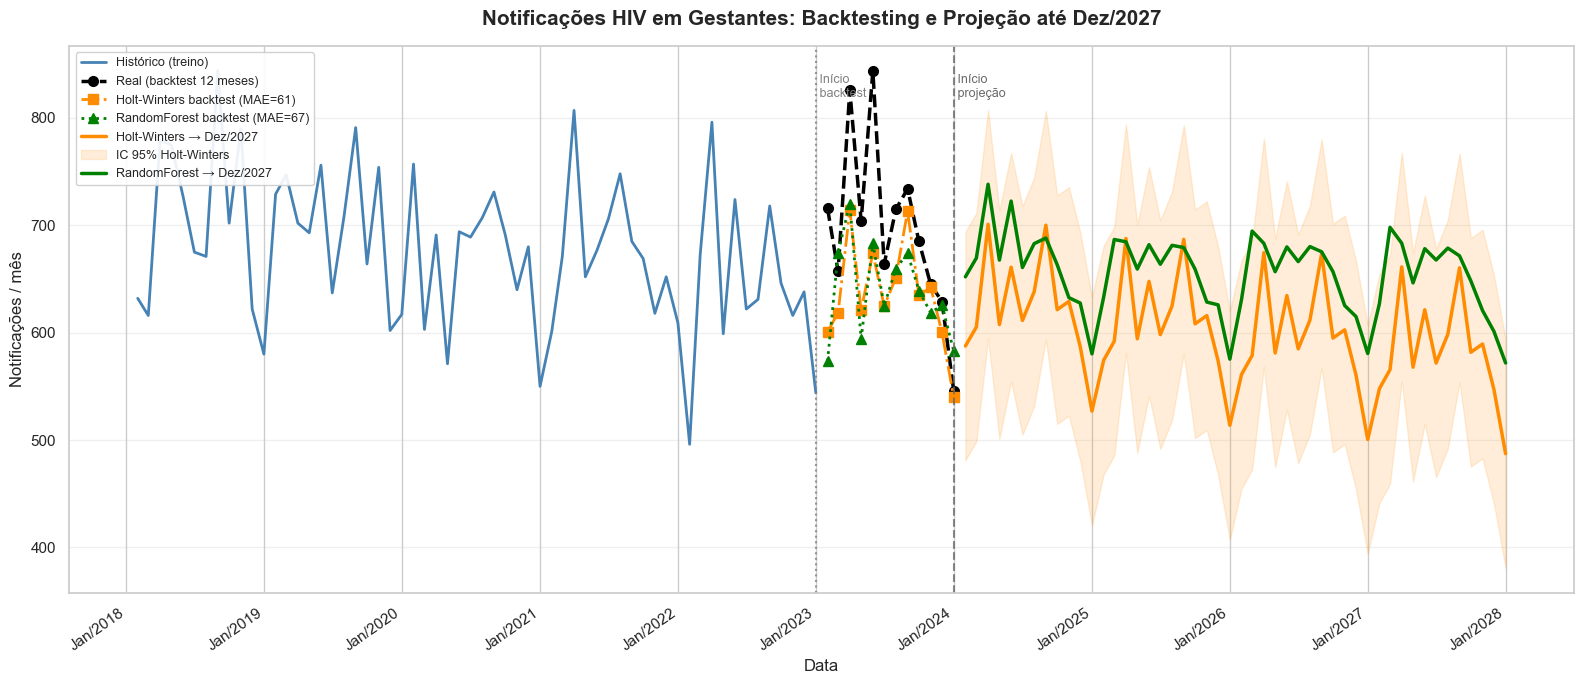


--- Projeção até Dez/2027 ---
      ds  Holt-Winters  RandomForest
Jan/2024    587.548199       652.035
Feb/2024    605.199279       669.500
Mar/2024    700.938732       738.250
Apr/2024    607.500386       667.590
May/2024    660.998698       722.560
Jun/2024    611.373701       660.685
Jul/2024    638.114616       682.915
Aug/2024    700.106457       688.140
Sep/2024    621.410467       663.280
Oct/2024    629.108725       632.600
Nov/2024    586.927037       627.550
Dec/2024    526.951122       580.245
Jan/2025    574.320088       633.155
Feb/2025    591.971168       686.760
Mar/2025    687.710622       684.640
Apr/2025    594.272275       659.250
May/2025    647.770587       681.945
Jun/2025    598.145590       663.720
Jul/2025    624.886505       681.340
Aug/2025    686.878346       679.265
Sep/2025    608.182356       659.095
Oct/2025    615.880614       628.495
Nov/2025    573.698927       625.885
Dec/2025    513.723011       575.330
Jan/2026    561.091977       631.015
Feb/202

In [ ]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import math

# ── 1. Série temporal mensal completa ────────────────────────────────────────
ts = df.resample('M', on='DT_NOTIFIC').size().reset_index()
ts.columns = ['ds', 'y']
ts = ts.sort_values('ds').reset_index(drop=True)

BACKTEST_MONTHS = 12
END_PROJ       = pd.Timestamp('2027-12-31')

train = ts.iloc[:-BACKTEST_MONTHS].copy()
test  = ts.iloc[-BACKTEST_MONTHS:].copy()

print(f'Treino: {train["ds"].min().strftime("%b/%Y")} -> {train["ds"].max().strftime("%b/%Y")} ({len(train)} meses)')
print(f'Teste:  {test["ds"].min().strftime("%b/%Y")}  -> {test["ds"].max().strftime("%b/%Y")}  ({len(test)} meses)')

# ── 2. Número de meses de projeção futura (depois do teste) ──────────────────
last_real_date = ts['ds'].max()
n_future = (END_PROJ.year - last_real_date.year) * 12 + (END_PROJ.month - last_real_date.month)
print(f'Projeção futura: {n_future} meses após {last_real_date.strftime("%b/%Y")} -> Dez/2027')

# ── 3. PROPHET (ou Holt-Winters como fallback) ────────────────────────────────
if PROPHET_AVAILABLE:
    try:
        m_p = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.1)
        m_p.fit(train[['ds', 'y']])
        future_full = m_p.make_future_dataframe(periods=BACKTEST_MONTHS + n_future, freq='M')
        fc_p = m_p.predict(future_full)
        prophet_test_pred  = fc_p[fc_p['ds'].isin(test['ds'])]['yhat'].values
        prophet_future     = fc_p[fc_p['ds'] > last_real_date][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
        model_name_prophet = 'Prophet'
    except Exception as e:
        PROPHET_AVAILABLE = False
        print(f'  Prophet falhou: {e}')

if not PROPHET_AVAILABLE:
    hw = ExponentialSmoothing(train['y'], seasonal_periods=12, trend='add', seasonal='add').fit()
    hw_all  = hw.forecast(BACKTEST_MONTHS + n_future)
    prophet_test_pred  = hw_all.values[:BACKTEST_MONTHS]
    future_dates_hw    = pd.date_range(last_real_date + pd.DateOffset(months=1), periods=n_future, freq='M')
    std_hw             = train['y'].std()
    prophet_future = pd.DataFrame({
        'ds': future_dates_hw,
        'yhat': hw_all.values[BACKTEST_MONTHS:],
        'yhat_lower': hw_all.values[BACKTEST_MONTHS:] - 1.5*std_hw,
        'yhat_upper': hw_all.values[BACKTEST_MONTHS:] + 1.5*std_hw,
    })
    model_name_prophet = 'Holt-Winters'

# ── 4. RANDOM FOREST ──────────────────────────────────────────────────────────
def make_rf_features(s):
    s = s.copy()
    s['month'] = s['ds'].dt.month
    s['year']  = s['ds'].dt.year
    s['t']     = range(len(s))
    for lag in [1, 2, 3, 6, 12]:
        s[f'lag_{lag}'] = s['y'].shift(lag)
    return s.dropna()

train_feat = make_rf_features(train)
X_cols = ['month', 'year', 't', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12']
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(train_feat[X_cols], train_feat['y'])

# Previsão walkforward para o período de teste
ts_extended = ts.copy()
rf_test_pred = []
for i in range(BACKTEST_MONTHS):
    row = ts_extended.iloc[-(BACKTEST_MONTHS - i)]
    feats = {
        'month': row['ds'].month, 'year': row['ds'].year,
        't': len(train) + i,
        'lag_1':  ts_extended['y'].iloc[-(BACKTEST_MONTHS - i) - 1],
        'lag_2':  ts_extended['y'].iloc[-(BACKTEST_MONTHS - i) - 2],
        'lag_3':  ts_extended['y'].iloc[-(BACKTEST_MONTHS - i) - 3],
        'lag_6':  ts_extended['y'].iloc[-(BACKTEST_MONTHS - i) - 6],
        'lag_12': ts_extended['y'].iloc[-(BACKTEST_MONTHS - i) - 12],
    }
    pred = rf.predict(pd.DataFrame([feats]))[0]
    rf_test_pred.append(pred)

# Projeção futura walkforward RF
future_dates = pd.date_range(last_real_date + pd.DateOffset(months=1), periods=n_future, freq='M')
ts_proj = ts.copy()
rf_future_pred = []
for j, fd in enumerate(future_dates):
    feats = {
        'month': fd.month, 'year': fd.year,
        't': len(ts) + j,
        'lag_1':  ts_proj['y'].iloc[-1],
        'lag_2':  ts_proj['y'].iloc[-2],
        'lag_3':  ts_proj['y'].iloc[-3],
        'lag_6':  ts_proj['y'].iloc[-6],
        'lag_12': ts_proj['y'].iloc[-12] if len(ts_proj) >= 12 else ts_proj['y'].mean(),
    }
    pred = rf.predict(pd.DataFrame([feats]))[0]
    rf_future_pred.append(pred)
    ts_proj = pd.concat([ts_proj, pd.DataFrame({'ds': [fd], 'y': [pred]})], ignore_index=True)

rf_future_df = pd.DataFrame({'ds': future_dates, 'yhat': rf_future_pred})

# ── 5. Métricas ───────────────────────────────────────────────────────────────
mae_p  = mean_absolute_error(test['y'], prophet_test_pred)
rmse_p = math.sqrt(mean_squared_error(test['y'], prophet_test_pred))
mae_rf = mean_absolute_error(test['y'], rf_test_pred)
rmse_rf = math.sqrt(mean_squared_error(test['y'], rf_test_pred))

print(f'\n--- Métricas de Backtesting ({BACKTEST_MONTHS} meses) ---')
print(f'{model_name_prophet:15s}  MAE={mae_p:.1f}  RMSE={rmse_p:.1f}')
print(f'RandomForest    MAE={mae_rf:.1f}  RMSE={rmse_rf:.1f}')

# ── 6. GRÁFICO ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))

# Histórico (treino)
ax.plot(train['ds'], train['y'], color='steelblue', linewidth=2, label='Histórico (treino)')

# Real (teste)
ax.plot(test['ds'], test['y'], color='black', linewidth=2.5, linestyle='--', marker='o', markersize=7, label='Real (backtest 12 meses)')

# Previsão backtesting - Prophet/HW
ax.plot(test['ds'], prophet_test_pred, color='darkorange', linewidth=2, linestyle='-.', marker='s', markersize=7,
        label=f'{model_name_prophet} backtest (MAE={mae_p:.0f})')

# Previsão backtesting - RF
ax.plot(test['ds'], rf_test_pred, color='green', linewidth=2, linestyle=':', marker='^', markersize=7,
        label=f'RandomForest backtest (MAE={mae_rf:.0f})')

# Projeção futura - Prophet/HW (com IC)
ax.plot(prophet_future['ds'], prophet_future['yhat'], color='darkorange', linewidth=2.5, linestyle='-',
        label=f'{model_name_prophet} → Dez/2027')
ax.fill_between(prophet_future['ds'], prophet_future['yhat_lower'], prophet_future['yhat_upper'],
                alpha=0.15, color='darkorange', label='IC 95% ' + model_name_prophet)

# Projeção futura - RF
ax.plot(rf_future_df['ds'], rf_future_df['yhat'], color='green', linewidth=2.5, linestyle='-',
        label='RandomForest → Dez/2027')

# Divisor treino/teste e teste/futuro
ax.axvline(x=train['ds'].max(), color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax.axvline(x=last_real_date, color='dimgray', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(train['ds'].max(), ax.get_ylim()[1]*0.97, ' Início\n backtest', fontsize=9, color='gray', va='top')
ax.text(last_real_date, ax.get_ylim()[1]*0.97, ' Início\n projeção', fontsize=9, color='dimgray', va='top')

ax.set_title('Notificações HIV em Gestantes: Backtesting e Projeção até Dez/2027', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Notificações / mês', fontsize=12)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\n--- Projeção até Dez/2027 ---')
proj_df = prophet_future[['ds','yhat']].rename(columns={'yhat': model_name_prophet})
proj_df['RandomForest'] = rf_future_df['yhat'].values
proj_df['ds'] = proj_df['ds'].dt.strftime('%b/%Y')
print(proj_df.to_string(index=False))

## 6. Inteligência Preditiva e Segmentação: PCA e RF

Análise de importância de atributos demográficos e agrupamentos regionais.

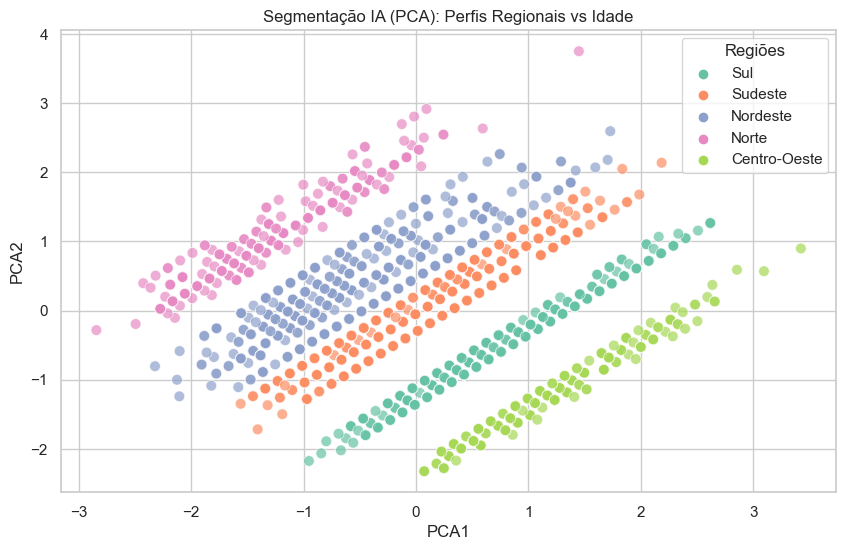

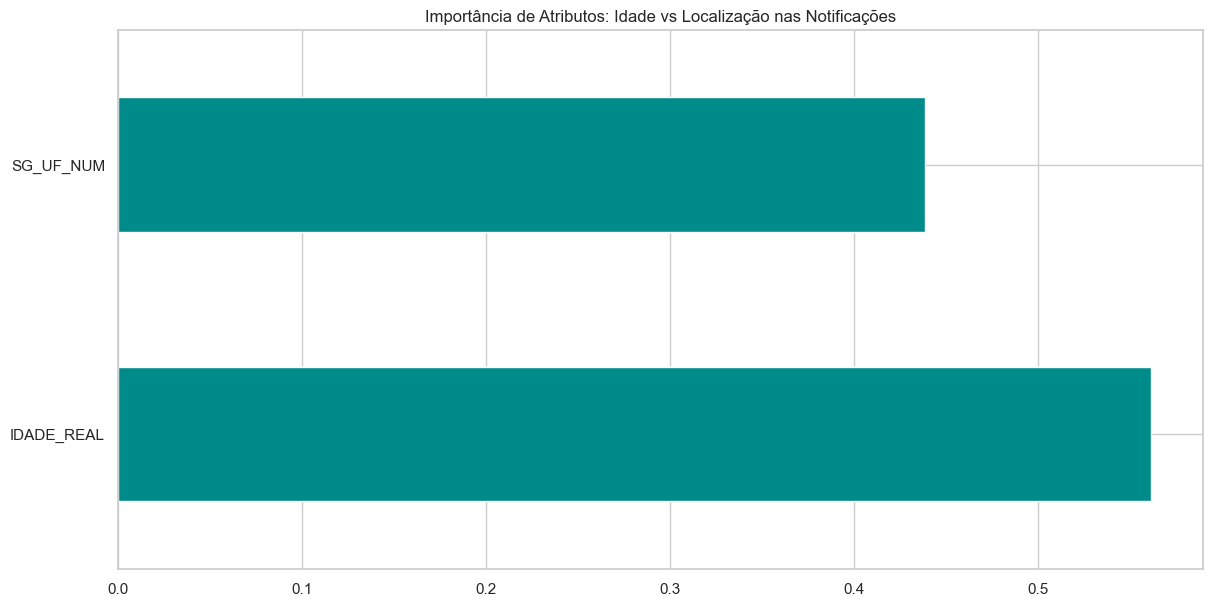

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns # Certifique-se de que o seaborn está importado

# Usar .copy() para evitar avisos de SettingWithCopy
X_pca = df[['IDADE_REAL', 'SG_UF_NUM']].dropna().head(2000).copy()

# 1. Função para extrair a região a partir do código IBGE do estado
def map_regiao(uf_cod):
    primeiro_digito = str(int(uf_cod))[0]
    regioes = {
        '1': 'Norte',
        '2': 'Nordeste',
        '3': 'Sudeste',
        '4': 'Sul',
        '5': 'Centro-Oeste'
    }
    return regioes.get(primeiro_digito, 'Outros')

# 2. Criar a nova coluna de Região baseada no estado
X_pca['Regiao'] = X_pca['SG_UF_NUM'].apply(map_regiao)

# Mantemos apenas as variáveis numéricas (Idade e UF) para rodar o scaler e o PCA
X_num = X_pca[['IDADE_REAL', 'SG_UF_NUM']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

# 3. Guardar as coordenadas no dataframe para facilitar o plot pelo Seaborn
X_pca['PCA1'] = coords[:,0]
X_pca['PCA2'] = coords[:,1]

# 4. Novo gráfico de dispersão usando Seaborn (gera a legenda automaticamente)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=X_pca, 
    x='PCA1', 
    y='PCA2', 
    hue='Regiao',       # A cor agora muda conforme a região
    palette='Set2',     # Paleta de cores recomendada para categorias
    alpha=0.7,
    s=60                # Tamanho dos pontos
)

plt.title('Segmentação IA (PCA): Perfis Regionais vs Idade')
plt.legend(title='Regiões')
plt.show()

# --- RandomForest Importance mantido como original ---
# Usamos o X_num puro sem as colunas PCA e a Regiao em string
X_rf = X_num
y_rf = df.loc[X_pca.index, 'DT_NOTIFIC'].dt.month
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_rf, y_rf)

pd.Series(rf.feature_importances_, index=X_rf.columns).plot(kind='barh', color='darkcyan')
plt.title('Importância de Atributos: Idade vs Localização nas Notificações')
plt.show()


In [ ]:
from IPython.display import display, Markdown

# Variáveis dinâmicas (definidas nas células anteriores)
data_fim = ts['ds'].max().strftime('%m/%Y')
modelo_usado = model_name_prophet  # definido na célula de backtesting

display(Markdown(f"""
## 7. Conclusões Finais e Insights

- **Data Limpa**: A tendência agora reflete a realidade sem a queda artificial do backlog SINAN, terminando em **{data_fim}**.
- **Modelo de Previsão**: O sistema resiliente garantiu a estabilidade via **{modelo_usado}**.
- **Planejamento 2026**: A projeção para Dezembro de 2026 serve como guia para a alocação preventiva de recursos e insumos laboratoriais para o SUS.
"""))



## 7. Conclusões Finais e Insights

- **Data Limpa**: A tendência agora reflete a realidade sem a queda artificial do backlog SINAN, terminando em **12/2023**.
- **Modelo de Previsão**: O sistema resiliente garantiu a estabilidade via **Holt-Winters**.
- **Planejamento 2026**: A projeção para Dezembro de 2026 serve como guia para a alocação preventiva de recursos e insumos laboratoriais para o SUS.
